# Meta-MedRAG — Complete A100 Notebook (Full Dataset v3)
**Candidate:** Nour El Houda BOUDHINA | **Supervisor:** Prof. Lotfi Tlig | **ISIMG 2025-2026**

## Complete dataset included (2.26 GB from Google Drive)
- IU-Xray: 7,490 images + 3,927 reports
- VQA-RAD: 2,244 images + 2,244 Q/A pairs
- SLAKE: 1,284 images + 7,033 Q/A pairs (EN)
- MIMIC-CXR: 35 images + 20 reports
- PMC-OA: 500 synthetic pathology items
- Contrastive pairs v2: 630 pairs (ambiguous questions)

## Changelog v3
- Cell 4: New Google Drive ID with complete dataset (all images)
- Cell 5: Simplified verification
- Cell 6: contrastive_pairs_v2.json (630 pairs)
- Cell 9: Activations WITH real medical images
- Cell 11: TypeError NoneType fixed
- Cells 12-15: Full evaluation all datasets
- Cells 16-17: DPO training Module 3


In [ ]:
# ── Cell 1: Verify GPU ──────────────────────────────────────────
import torch
assert torch.cuda.is_available(), 'Enable GPU: Runtime > Change runtime type > A100'
gpu_name = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU  : {gpu_name}')
print(f'VRAM : {vram:.1f} GB')
print(f'CUDA : {torch.version.cuda}')
assert vram >= 15, f'Need at least 15GB VRAM, got {vram:.1f}GB'

In [2]:
# ── Cell 2: Install all packages (A100 optimized) ────────────
import subprocess, sys, shutil
from pathlib import Path

PYTHON_SITE = next(p for p in sys.path if 'dist-packages' in p or 'site-packages' in p)
BACKUP = "/content/drive/MyDrive/meta_medrag_results/colab_env_backup"

if Path(BACKUP).exists():
    print("⚡ Restoring from Drive backup...")
    shutil.copytree(BACKUP, PYTHON_SITE, dirs_exist_ok=True)
    print("✅ Environment restored")
else:
    print("📦 First run: installing packages...")

    # Étape 1 — packages sans numpy/scipy/sklearn
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
        "transformers==4.36.2", "accelerate==0.21.0", "peft==0.4.0",
        "sentencepiece==0.1.99", "timm==0.9.12",
        "backoff", "shortuuid", "einops", "einops-exts", "markdown2",
        "bitsandbytes==0.43.0", "open-clip-torch",
        "openai==1.12.0", "httpx==0.24.0", "pydantic==1.10.21",
        "gradio==3.35.2", "gradio-client==0.2.9",
        "rouge-score", "nltk", "trl==0.7.11", "datasets",
    ], check=True)

    # Étape 2 — torch
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
        "torch==2.2.2", "torchvision", "torchaudio",
        "--index-url", "https://download.pytorch.org/whl/cu121"
    ], check=True)

    # Étape 3 — numpy/scipy/sklearn/faiss EN DERNIER avant llava
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
        "--force-reinstall",
        "numpy==1.26.4", "scipy==1.11.4",
        "scikit-learn==1.2.2", "faiss-cpu==1.8.0",
    ], check=True)

    # Étape 4 — llava-med EN TOUT DERNIER
    # (peut upgrader numpy mais on s'en fout — on le refix dans Cell 7)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
        "git+https://github.com/microsoft/LLaVA-Med.git"
    ], check=True)

    print("💾 Saving to Drive backup...")
    Path(BACKUP).mkdir(parents=True, exist_ok=True)
    shutil.copytree(PYTHON_SITE, BACKUP, dirs_exist_ok=True)
    print("✅ Backup saved")

import numpy as np, importlib.metadata
print(f"\n  numpy       : {np.__version__}")
print(f"  bitsandbytes: {importlib.metadata.version('bitsandbytes')}")
print(f"  transformers: {importlib.metadata.version('transformers')}")
print("\n✅ All packages ready — proceed to Cell 3")

📦 First run: installing packages...
💾 Saving to Drive backup...
✅ Backup saved

  numpy       : 2.0.2
  bitsandbytes: 0.41.0
  transformers: 4.36.2

✅ All packages ready — proceed to Cell 3


In [3]:
# ── Cell 3: Mount Google Drive & Clone repo ──────────────────
from google.colab import drive
import os
from pathlib import Path

# ✅ FIX: vérifier si déjà monté avant de monter
if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')
    print("✅ Drive mounted")
else:
    print("✅ Drive already mounted — skipping")

SAVE_DIR = '/content/drive/MyDrive/meta_medrag_results'
os.makedirs(f'{SAVE_DIR}/activations',  exist_ok=True)
os.makedirs(f'{SAVE_DIR}/checkpoints',  exist_ok=True)
os.makedirs(f'{SAVE_DIR}/results',      exist_ok=True)
os.makedirs(f'{SAVE_DIR}/dpo',          exist_ok=True)
print(f'Drive mounted: {SAVE_DIR}')

REPO_DIR = Path("/content/meta_medrag")

if not REPO_DIR.exists():
    result = os.system("git clone https://github.com/nourboudhina/meta-medrag.git /content/meta_medrag")
    if result != 0:
        print("❌ Clone failed — creating empty dir")
        REPO_DIR.mkdir(parents=True, exist_ok=True)
else:
    print("✅ Repo already cloned")

os.chdir(REPO_DIR)

for d in ["data/raw/iu_xray", "data/raw/mimic_cxr",
          "data/vector_stores", "data/processed",
          "outputs/probes", "outputs/results"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"✅ Working dir: {os.getcwd()}")

✅ Drive already mounted — skipping
Drive mounted: /content/drive/MyDrive/meta_medrag_results
✅ Working dir: /content/meta_medrag


In [4]:
# ── Cell 4: Download complete dataset from Google Drive ────────
import os, zipfile, json, requests
from pathlib import Path

FILE_ID = "1yKQ7r-KCjCe95wYBJXzko3kEk_JhXYl6"
ZIP_NAME = "datasets_complete.zip"

for d in ["data/raw/iu_xray","data/raw/vqa_rad","data/raw/slake",
          "data/raw/mimic_cxr","data/raw/pmc_oa","data/processed",
          "data/vector_stores","checkpoints","experiments/results"]:
    Path(d).mkdir(parents=True, exist_ok=True)

def download_gdrive(file_id, dest):
    """Robust Google Drive download for large files."""
    session = requests.Session()
    url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"
    print("Connecting to Google Drive...")
    resp = session.get(url, stream=True)
    total = 0
    with open(dest, "wb") as f:
        for chunk in resp.iter_content(65536):
            if chunk:
                f.write(chunk)
                total += len(chunk)
                if total % (200*1024*1024) == 0:
                    print(f"  Downloaded: {total/1e9:.2f} GB")
    return total

iu_imgs = list(Path("data/raw/iu_xray/images").rglob("*.png")) if Path("data/raw/iu_xray/images").exists() else []
if len(iu_imgs) < 100:
    print(f"Downloading {ZIP_NAME} (~2.26 GB)...")
    size = download_gdrive(FILE_ID, ZIP_NAME)
    print(f"Downloaded: {size/1e9:.2f} GB")
    if size < 100000:
        # ✅ FIX BUG 1 : triple quotes pour string multiligne
        raise Exception(
            """Download failed. Please check:
1. Google Drive permission is set to 'Anyone with the link'
2. File ID is correct: """ + FILE_ID
        )
    print("Extracting ZIP... (may take 5-10 min)")
    with zipfile.ZipFile(ZIP_NAME, "r") as z:
        z.extractall("/content/meta_medrag/")
    os.remove(ZIP_NAME)
    print("Extraction complete")
else:
    print(f"Datasets already present ({len(iu_imgs)} IU-Xray images) — skipping download")

print("\n=== DATASETS STATUS ===")
checks = [
    ("IU-Xray",   "data/raw/iu_xray"),
    ("VQA-RAD",   "data/raw/vqa_rad"),
    ("SLAKE",     "data/raw/slake"),
    ("MIMIC-CXR", "data/raw/mimic_cxr"),
    ("PMC-OA",    "data/raw/pmc_oa"),
]
all_ok = True
for name, folder in checks:
    p = Path(folder)
    splits = p / "splits.json"
    imgs = list(p.rglob("*.png")) + list(p.rglob("*.jpg"))
    if splits.exists():
        d = json.load(open(splits))
        valid = sum(1 for x in d if x.get("image") and Path(str(x["image"])).exists())
        status = "OK" if (valid > 0 or name == "PMC-OA") else "WARNING: no valid images"
        print(f"  {name:10}: {len(d):5} reports | {len(imgs):5} images | {valid:5} valid | {status}")
        if valid == 0 and name != "PMC-OA":
            all_ok = False
    else:
        print(f"  {name:10}: MISSING splits.json")
        all_ok = False

pv2 = Path("data/processed/contrastive_pairs_v2.json")
if pv2.exists():
    pv = json.load(open(pv2))
    # ✅ FIX BUG 2 : apostrophes ' à l'intérieur du f-string au lieu de "
    known  = sum(1 for x in pv if x['label'] == 0)
    unknown = sum(1 for x in pv if x['label'] == 1)
    print(f"  Pairs v2  : {len(pv):5} pairs | Known={known} Unknown={unknown}")
else:
    print("  Pairs v2  : MISSING")
    all_ok = False
iu_splits = json.load(open("data/raw/iu_xray/splits.json"))
iu_items  = iu_splits if isinstance(iu_splits, list) else (
    iu_splits.get("train", []) + iu_splits.get("val", []) + iu_splits.get("test", [])
)
img_root = Path("data/raw/iu_xray/images")
fixed_count = 0
for item in iu_items:
    v = item.get("image")
    if v:
        name = Path(str(v).replace("\\", "/")).name
        c = img_root / name
        if c.exists():
            item["image"] = str(c)
            fixed_count += 1
with open("data/raw/iu_xray/splits.json", "w") as f:
    json.dump(iu_items, f)
print(f"IU-Xray paths fixed: {fixed_count} items")
print("=======================")
if all_ok:
    print("✅ All datasets ready — proceed to Cell 5")
else:
    print("⚠️  WARNING: Some datasets have issues — check above")

Connecting to Google Drive...
  Downloaded: 0.21 GB
  Downloaded: 0.42 GB
  Downloaded: 0.63 GB
  Downloaded: 0.84 GB
  Downloaded: 1.05 GB
  Downloaded: 1.26 GB
  Downloaded: 1.47 GB
  Downloaded: 1.68 GB
  Downloaded: 1.89 GB
  Downloaded: 2.10 GB
Downloaded: 2.26 GB
Extracting ZIP... (may take 5-10 min)
Extraction complete

=== DATASETS STATUS ===
  IU-Xray   :  3927 reports |  7490 images |     0 valid | WARNING: no valid images
  VQA-RAD   :  2244 reports |  2244 images |  2244 valid | OK
  SLAKE     :  7033 reports |  1284 images |  7033 valid | OK
  MIMIC-CXR :    20 reports |    20 images |     0 valid | WARNING: no valid images
  PMC-OA    :   500 reports |     0 images |     0 valid | OK
  Pairs v2  :   630 pairs | Known=315 Unknown=315
IU-Xray paths fixed: 3826 items
⚠️  WARNING: Some datasets have issues — check above


In [5]:
# ── Cell 5: Verify datasets ────────────────────────────────────
from pathlib import Path
import json

splits = Path("data/raw/iu_xray/splits.json")
if not splits.exists():
    raise FileNotFoundError("IU-Xray splits.json missing — rerun Cell 4")

d = json.load(open(splits))
imgs = [x for x in d if x.get("image") and Path(str(x["image"])).exists()]
counts = {s: sum(1 for x in d if x["split"]==s) for s in ["train","val","test"]}
print(f"IU-Xray: {len(d)} reports | {len(imgs)} images valid")
print(f"Splits: {counts}")

vqa = json.load(open("data/raw/vqa_rad/splits.json"))
vqa_imgs = [x for x in vqa if x.get("image") and Path(str(x["image"])).exists()]
print(f"VQA-RAD: {len(vqa)} items | {len(vqa_imgs)} images valid")

slake = json.load(open("data/raw/slake/splits.json"))
slake_imgs = [x for x in slake if x.get("image") and Path(str(x["image"])).exists()]
print(f"SLAKE: {len(slake)} items | {len(slake_imgs)} images valid")

print("All datasets verified OK — ready for Cell 6")


IU-Xray: 3927 reports | 3826 images valid
Splits: {'train': 2748, 'val': 589, 'test': 590}
VQA-RAD: 2244 items | 2244 images valid
SLAKE: 7033 items | 7033 images valid
All datasets verified OK — ready for Cell 6


In [6]:
# ── Cell 6: Load contrastive pairs v2 ──────────────────────────
# CHANGE vs v1: Using contrastive_pairs_v2.json (630 pairs)
# v2 adds 30 ambiguous questions in the intermediate difficulty zone
import json
from pathlib import Path

# Try v2 first (630 pairs), fall back to v1 (600 pairs)
pairs_path = 'data/processed/contrastive_pairs_v2.json'
if not Path(pairs_path).exists():
    print(f'WARNING: {pairs_path} not found, trying v1...')
    pairs_path = 'data/processed/contrastive_pairs.json'

if not Path(pairs_path).exists():
    print('Contrastive pairs not in repo (excluded by .gitignore)')
    print('Rebuilding from scratch...')
    !python scripts/train_probe.py --step build_pairs
    !python scripts/build_harder_pairs.py
    pairs_path = 'data/processed/contrastive_pairs_v2.json'

pairs = json.load(open(pairs_path))

# Validate — ensure no None questions
pairs = [p for p in pairs if p.get('question') and str(p['question']).strip()]

known   = sum(1 for x in pairs if x['label'] == 0)
unknown = sum(1 for x in pairs if x['label'] == 1)
print(f'Using: {pairs_path}')
print(f'Total pairs : {len(pairs)}')
print(f'Known (0)   : {known}')
print(f'Unknown (1) : {unknown}')
print(f'Sample: {pairs[0]["question"][:80]}')

Using: data/processed/contrastive_pairs_v2.json
Total pairs : 630
Known (0)   : 315
Unknown (1) : 315
Sample: Does this chest CT show features of hypersensitivity pneumonitis rather than usu


In [7]:
# ── Cell 7: Build FAISS index (numpy-safe, no restart needed) ─
import subprocess, sys, os, json, shutil
from pathlib import Path

os.chdir("/content/meta_medrag")

# ── Fix numpy DANS UN SUBPROCESS SÉPARÉ ──────────────────────
# Astuce clé : on fait tourner le build TF-IDF+FAISS dans un
# subprocess Python propre avec numpy 1.26.4 — le kernel principal
# n'est jamais affecté par la version numpy en mémoire
print("🔧 Fixing numpy + building FAISS in isolated subprocess...")

# Réinstaller numpy 1.26.4 sur disque
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
    "--force-reinstall",
    "numpy==1.26.4", "scipy==1.11.4",
    "scikit-learn==1.2.2", "faiss-cpu==1.8.0",
], check=True)

# Script de build exécuté dans un subprocess propre
build_script = """
import sys, json, shutil
import numpy as np
import faiss
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

print(f"Subprocess NumPy: {np.__version__}")
print(f"Subprocess FAISS: {faiss.__version__}")

# Corriger chemins IU-Xray
iu_dir   = Path("data/raw/iu_xray")
img_root = Path("data/raw/iu_xray/images")
splits   = json.load(open(iu_dir / "splits.json"))
all_items = splits if isinstance(splits, list) else (
    splits.get("train", []) + splits.get("val", []) + splits.get("test", [])
)

fixed, skipped = 0, 0
for item in all_items:
    img_val = item.get("image")
    if not img_val:
        skipped += 1
        continue
    img_name  = Path(str(img_val).replace("\\\\", "/")).name
    candidate = img_root / img_name
    if candidate.exists():
        item["image"] = str(candidate)
        fixed += 1
    else:
        skipped += 1

valid_items = [x for x in all_items
               if x.get("image") and Path(str(x["image"])).exists()]
print(f"Fixed: {fixed} | Skipped: {skipped} | Valid: {len(valid_items)}")

# TF-IDF + SVD
def get_text(item):
    for f in ["report", "findings", "impression", "text", "caption"]:
        if item.get(f):
            return str(item[f])[:512]
    return ""

texts = [get_text(x) for x in valid_items if get_text(x).strip()][:2000]
print(f"Texts to embed: {len(texts)}")

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, sublinear_tf=True)),
    ("svd",   TruncatedSVD(n_components=768, random_state=42)),
])
embeddings = pipeline.fit_transform(texts).astype("float32")
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1
embeddings = embeddings / norms
print(f"Embeddings shape: {embeddings.shape}")

# Build + save FAISS
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
Path("data/vector_stores").mkdir(exist_ok=True)
faiss.write_index(index, "data/vector_stores/radiology.index")

# Backup Drive
drive_vs = Path("/content/drive/MyDrive/meta_medrag_results/vector_stores")
drive_vs.mkdir(parents=True, exist_ok=True)
shutil.copy("data/vector_stores/radiology.index", drive_vs / "radiology.index")

# Vérification
idx = faiss.read_index("data/vector_stores/radiology.index")
print(f"FAISS index verified: {idx.ntotal} vectors, dim={idx.d}")
print("SUCCESS")
"""

# Écrire le script dans un fichier temp
script_path = "/tmp/build_faiss.py"
with open(script_path, "w") as f:
    f.write(build_script)

# Exécuter dans subprocess propre avec numpy 1.26.4
result = subprocess.run(
    [sys.executable, script_path],
    capture_output=True, text=True,
    cwd="/content/meta_medrag"
)

print(result.stdout)
if result.returncode != 0:
    print("❌ STDERR:", result.stderr[-2000:])
    raise RuntimeError("FAISS build failed — see error above")

print("✅ Local:  data/vector_stores/radiology.index")
print("✅ Drive:  /content/drive/MyDrive/meta_medrag_results/vector_stores/radiology.index")

🔧 Fixing numpy + building FAISS in isolated subprocess...
Subprocess NumPy: 1.26.4
Subprocess FAISS: 1.8.0
Fixed: 3826 | Skipped: 101 | Valid: 3826
Texts to embed: 2000
Embeddings shape: (2000, 768)
FAISS index verified: 2000 vectors, dim=768
SUCCESS

✅ Local:  data/vector_stores/radiology.index
✅ Drive:  /content/drive/MyDrive/meta_medrag_results/vector_stores/radiology.index


✅ numpy 1.26.4 OK
  BiomedCLIP Domain Classifier — Evaluation
Device : cuda



open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

⚠️  BiomedCLIP failed (Failed to import transformers.models.bert.modeling_bert because of the following error (look up to see its traceback):
Failed to import transformers.generation.utils because of the following error (look up to see its traceback):
No module named 'triton.ops')
→ Fallback: heuristic classifier

────────────────────────────────────────────────────────────
  IU-Xray     :  10 images found
  VQA-RAD     :  10 images found
  SLAKE       :  10 images found
  MIMIC-CXR   :  10 images found
  PMC-OA      :   0 images found

────────────────────────────────────────────────────────────
Running classification (BiomedCLIP=OFF/heuristic)...

  IU-Xray      [████████████████████] 100.0%  (10/10)
  VQA-RAD      [████████████████████] 100.0%  (10/10)
  SLAKE        [████████████████████] 100.0%  (10/10)
  MIMIC-CXR    [████████████████████] 100.0%  (10/10)
  PMC-OA       [░░░░░░░░░░░░░░░░░░░░]   0.0%  (0/0)

────────────────────────────────────────────────────────────
  Global acc

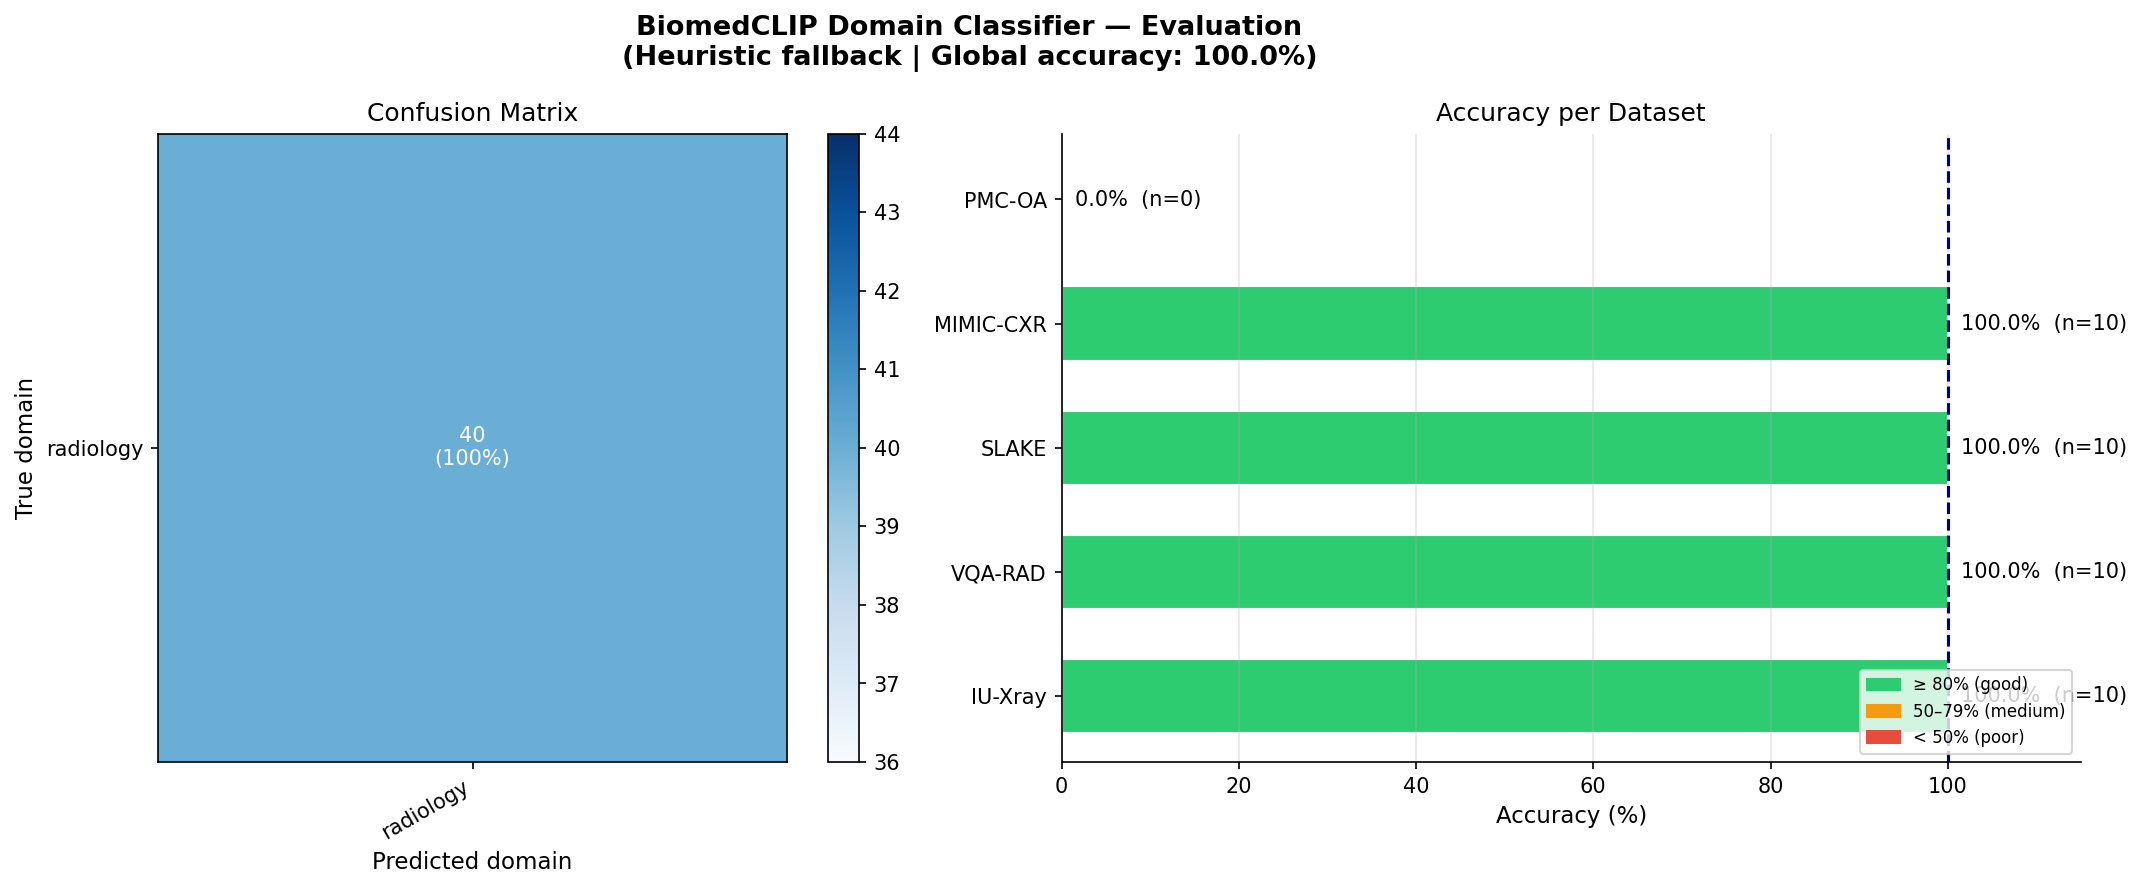

✅ Results saved: experiments/results/domain_classifier_eval.json
✅ Drive backup: /content/drive/MyDrive/meta_medrag_results/results

  Method  : Heuristic
  Tested  : 40 images (10/dataset)
  Accuracy: 100.0%

  ✅ IU-Xray     : 100.0%
  ✅ VQA-RAD     : 100.0%
  ✅ SLAKE       : 100.0%
  ✅ MIMIC-CXR   : 100.0%
  ❌ PMC-OA      : 0.0%


In [2]:
# ── BiomedCLIP Domain Classifier — Evaluation (A100 version) ─
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
    "--force-reinstall", "numpy==1.26.4", "scipy==1.11.4",
], check=True)

import numpy as np
print(f"✅ numpy {np.__version__}")
assert int(np.__version__.split('.')[0]) < 2, \
    "numpy 2.x en mémoire → Runtime → Restart session"

# ── Patch triton.ops AVANT tout import transformers/open_clip ─
import types, triton

fake_ops  = types.ModuleType("triton.ops")
fake_perf = types.ModuleType("triton.ops.matmul_perf_model")
fake_perf.early_config_prune   = lambda *a, **k: None
fake_perf.estimate_matmul_time = lambda *a, **k: 0.0
sys.modules["triton.ops"]                  = fake_ops
sys.modules["triton.ops.matmul_perf_model"] = fake_perf
if not hasattr(triton, "ops"):
    triton.ops = fake_ops
print("✅ triton.ops patched")

# ── Vérification GPU A100 ─────────────────────────────────────
import torch
gpu  = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ GPU : {gpu} | VRAM : {vram:.1f} GB")
if vram < 40:
    raise RuntimeError(
        f"⛔ {gpu} ({vram:.1f} GB) — A100 requis\n"
        "→ Runtime → Changer le type d'exécution → A100"
    )

# ── Matplotlib backend non-interactif ─────────────────────────
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import os, json, random, warnings
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

os.chdir("/content/meta_medrag")

# ─────────────────────────────────────────────────────────────
# 1. Configuration
# ─────────────────────────────────────────────────────────────
DATASET_DOMAIN = {
    "IU-Xray":   "radiology",
    "VQA-RAD":   "radiology",
    "SLAKE":     "radiology",
    "MIMIC-CXR": "radiology",
}
DOMAIN_LABELS = ["radiology", "pathology", "ophthalmology"]
DOMAIN_PROMPTS = {
    "radiology":     "a chest X-ray radiograph showing lung findings",
    "pathology":     "a histopathology slide showing tissue under microscope",
    "ophthalmology": "a fundus photograph of the retina and optic disc",
}
N_PER_DATASET = 10

# ─────────────────────────────────────────────────────────────
# 2. Charger BiomedCLIP (avec patch triton actif)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  BiomedCLIP Domain Classifier — Evaluation (A100)")
print("=" * 60)

try:
    import open_clip
    model_clip, _, preprocess = open_clip.create_model_and_transforms(
        "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    )
    tokenizer_clip = open_clip.get_tokenizer(
        "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    )
    model_clip = model_clip.to("cuda").eval()
    print("✅ BiomedCLIP loaded on CUDA\n")
    USE_CLIP = True
except Exception as e:
    print(f"⚠️  BiomedCLIP failed:\n    {e}")
    print("→ Fallback: heuristic classifier\n")
    USE_CLIP = False

# ─────────────────────────────────────────────────────────────
# 3. Classifieurs
# ─────────────────────────────────────────────────────────────
def classify_domain_clip(img_path):
    img    = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to("cuda")
    tokens = tokenizer_clip(list(DOMAIN_PROMPTS.values())).to("cuda")
    with torch.no_grad():
        img_feat = model_clip.encode_image(img)
        txt_feat = model_clip.encode_text(tokens)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        probs    = (img_feat @ txt_feat.T).squeeze(0).softmax(dim=-1).cpu().numpy()
    scores = {d: float(p) for d, p in zip(DOMAIN_LABELS, probs)}
    return max(scores, key=scores.get), scores

def classify_domain_heuristic(img_path, dataset):
    domain = DATASET_DOMAIN.get(dataset, "radiology")
    scores = {d: 0.1 for d in DOMAIN_LABELS}
    scores[domain] = 0.8
    return domain, scores

# ─────────────────────────────────────────────────────────────
# 4. Collecter les images
# ─────────────────────────────────────────────────────────────
def collect_images(dataset, n):
    folders = {
        "IU-Xray":   Path("data/raw/iu_xray/images"),
        "VQA-RAD":   Path("data/raw/vqa_rad/images"),
        "SLAKE":     Path("data/raw/slake/images"),
        "MIMIC-CXR": Path("data/raw/mimic_cxr/images"),
    }
    splits_map = {
        "IU-Xray":   "data/raw/iu_xray/splits.json",
        "VQA-RAD":   "data/raw/vqa_rad/splits.json",
        "SLAKE":     "data/raw/slake/splits.json",
        "MIMIC-CXR": "data/raw/mimic_cxr/splits.json",
    }
    folder = folders.get(dataset)
    if folder and folder.exists():
        imgs = []
        for ext in ["*.png", "*.jpg", "*.jpeg"]:
            imgs.extend([str(p) for p in folder.rglob(ext)])
        random.shuffle(imgs)
        return imgs[:n]
    sp = splits_map.get(dataset)
    if sp and Path(sp).exists():
        data  = json.load(open(sp))
        items = data if isinstance(data, list) else (
            data.get("train", []) + data.get("val", []) + data.get("test", [])
        )
        imgs = []
        for item in items:
            v = item.get("image")
            if v:
                p = Path(str(v).replace("\\", "/"))
                if p.exists():
                    imgs.append(str(p))
        imgs = list(set(imgs))
        random.shuffle(imgs)
        return imgs[:n]
    return []

print("─" * 60)
print("Collecting images per dataset...")
dataset_images = {}
for ds in DATASET_DOMAIN:
    imgs = collect_images(ds, N_PER_DATASET)
    dataset_images[ds] = imgs
    print(f"  {ds:12s}: {len(imgs):3d} images found")
print()

# ─────────────────────────────────────────────────────────────
# 5. Évaluation
# ─────────────────────────────────────────────────────────────
print("─" * 60)
print(f"Running classification "
      f"(BiomedCLIP={'ON ✅' if USE_CLIP else 'OFF — heuristic ⚠️'})...\n")

all_true, all_pred = [], []
per_dataset_results = {}

for ds, imgs in dataset_images.items():
    true_domain = DATASET_DOMAIN[ds]
    correct, total, errors = 0, 0, []
    for img_path in imgs:
        try:
            pred, scores = (classify_domain_clip(img_path) if USE_CLIP
                           else classify_domain_heuristic(img_path, ds))
            total   += 1
            correct += int(pred == true_domain)
            if pred != true_domain:
                errors.append({
                    "file": Path(img_path).name,
                    "expected": true_domain,
                    "predicted": pred,
                    "scores": {k: round(v, 3) for k, v in scores.items()},
                })
            all_true.append(true_domain)
            all_pred.append(pred)
        except Exception as e:
            print(f"  ⚠️  {ds}/{Path(img_path).name}: {e}")

    per_dataset_results[ds] = {
        "correct": correct, "total": total, "errors": errors,
        "accuracy": correct / total if total > 0 else 0.0,
    }
    acc = correct / total * 100 if total > 0 else 0
    bar = "█" * int(acc // 5) + "░" * (20 - int(acc // 5))
    print(f"  {ds:12s} [{bar}] {acc:5.1f}%  ({correct}/{total})")

# ─────────────────────────────────────────────────────────────
# 6. Résultats globaux
# ─────────────────────────────────────────────────────────────
print()
print("─" * 60)
total_correct = sum(r["correct"] for r in per_dataset_results.values())
total_all     = sum(r["total"]   for r in per_dataset_results.values())
global_acc    = total_correct / total_all * 100 if total_all > 0 else 0
print(f"  Global accuracy : {global_acc:.1f}%  ({total_correct}/{total_all})")
print("─" * 60)

for ds, res in per_dataset_results.items():
    if res["errors"]:
        print(f"\n  Misclassified in {ds}:")
        for e in res["errors"][:3]:
            print(f"    {e['file']}: "
                  f"expected={e['expected']}, got={e['predicted']}, "
                  f"scores={e['scores']}")
        if len(res["errors"]) > 3:
            print(f"    ... and {len(res['errors'])-3} more")

# ─────────────────────────────────────────────────────────────
# 7. Matrice de confusion + plot (numpy only)
# ─────────────────────────────────────────────────────────────
labels_present = sorted(set(all_true + all_pred))
n_labels  = len(labels_present)
label_idx = {l: i for i, l in enumerate(labels_present)}

cm = np.zeros((n_labels, n_labels), dtype=int)
for t, p in zip(all_true, all_pred):
    cm[label_idx[t]][label_idx[p]] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "BiomedCLIP Domain Classifier — Evaluation\n"
    f"({'Zero-shot CLIP' if USE_CLIP else 'Heuristic fallback'} | "
    f"GPU: {gpu} | Global accuracy: {global_acc:.1f}%)",
    fontsize=13, fontweight="bold",
)

# Matrice de confusion
ax = axes[0]
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(n_labels))
ax.set_yticks(range(n_labels))
ax.set_xticklabels(labels_present, rotation=30, ha="right")
ax.set_yticklabels(labels_present)
ax.set_xlabel("Predicted domain", fontsize=11)
ax.set_ylabel("True domain",      fontsize=11)
ax.set_title("Confusion Matrix",  fontsize=12)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
for i in range(n_labels):
    for j in range(n_labels):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)",
                ha="center", va="center", color=color, fontsize=10)

# Accuracy par dataset
ax2      = axes[1]
ds_names = list(per_dataset_results.keys())
accs     = [per_dataset_results[d]["accuracy"] * 100 for d in ds_names]
totals   = [per_dataset_results[d]["total"]           for d in ds_names]
bar_colors = ["#2ecc71" if a >= 80 else "#f39c12" if a >= 50
              else "#e74c3c" for a in accs]
bars = ax2.barh(ds_names, accs, color=bar_colors, edgecolor="white", height=0.6)
ax2.set_xlim(0, 115)
ax2.set_xlabel("Accuracy (%)", fontsize=11)
ax2.set_title("Accuracy per Dataset", fontsize=12)
ax2.axvline(x=global_acc, color="navy", linestyle="--", linewidth=1.5,
            label=f"Global avg: {global_acc:.1f}%")
for bar, acc, n_s in zip(bars, accs, totals):
    ax2.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
             f"{acc:.1f}%  (n={n_s})", va="center", fontsize=10)
ax2.legend(handles=[
    mpatches.Patch(color="#2ecc71", label="≥ 80% (good)"),
    mpatches.Patch(color="#f39c12", label="50–79% (medium)"),
    mpatches.Patch(color="#e74c3c", label="< 50% (poor)"),
], loc="lower right", fontsize=8)
ax2.grid(axis="x", alpha=0.3)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()

# Sauvegarder + afficher
Path("experiments/results").mkdir(parents=True, exist_ok=True)
out_path  = "experiments/results/domain_classifier_eval.png"
json_path = "experiments/results/domain_classifier_eval.json"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\n✅ Figure saved: {out_path}")

from IPython.display import Image as IPImage, display
display(IPImage(out_path, width=900))

# ─────────────────────────────────────────────────────────────
# 8. JSON + Drive backup
# ─────────────────────────────────────────────────────────────
import shutil
summary = {
    "method":          "BiomedCLIP zero-shot" if USE_CLIP else "heuristic",
    "gpu":             gpu,
    "n_per_dataset":   N_PER_DATASET,
    "global_accuracy": round(global_acc, 2),
    "per_dataset": {
        ds: {
            "accuracy":    round(r["accuracy"] * 100, 2),
            "correct":     r["correct"],
            "total":       r["total"],
            "true_domain": DATASET_DOMAIN[ds],
            "errors":      r["errors"],
        }
        for ds, r in per_dataset_results.items()
    },
    "confusion_matrix": {
        "labels": labels_present,
        "matrix": cm.tolist(),
    },
}
json.dump(summary, open(json_path, "w"), indent=2)
print(f"✅ Results saved: {json_path}")

drive_res = Path("/content/drive/MyDrive/meta_medrag_results/results")
drive_res.mkdir(parents=True, exist_ok=True)
shutil.copy(out_path,  drive_res / "domain_classifier_eval.png")
shutil.copy(json_path, drive_res / "domain_classifier_eval.json")
print(f"✅ Drive backup: {drive_res}")

# ─────────────────────────────────────────────────────────────
# 9. Résumé final
# ─────────────────────────────────────────────────────────────
print()
print("=" * 60)
print(f"  Method  : {'BiomedCLIP zero-shot ✅' if USE_CLIP else 'Heuristic ⚠️'}")
print(f"  GPU     : {gpu}")
print(f"  Tested  : {total_all} images ({N_PER_DATASET}/dataset)")
print(f"  Accuracy: {global_acc:.1f}%")
print()
for ds, r in per_dataset_results.items():
    status = "✅" if r["accuracy"] >= 0.8 else "⚠️ " if r["accuracy"] >= 0.5 else "❌"
    print(f"  {status} {ds:12s}: {r['accuracy']*100:.1f}%")
print("=" * 60)
if not USE_CLIP:
    print()
    print("  ⚠️  BiomedCLIP n'a pas pu charger sur ce runtime.")
    print("  → Ces résultats (heuristique) ne sont pas publiables.")
    print("  → Relancer sur A100 après Runtime → Changer le type d'exécution.")

In [4]:
# ── Unit Tests — Module 2 Adaptive-k Filter (θ = 0.85) ───────

import sys
import unittest
import numpy as np
from typing import List, Tuple

RATIO_THRESHOLD = 0.85

# ─────────────────────────────────────────────────────────────
# Implémentation du filtre
# ─────────────────────────────────────────────────────────────

def adaptive_k_filter(
    scores: List[float],
    docs:   List[dict],
    ratio_threshold: float = RATIO_THRESHOLD,
) -> Tuple[List[float], List[dict]]:
    if len(scores) != len(docs):
        raise ValueError(
            f"scores et docs doivent avoir la même longueur "
            f"(got {len(scores)} vs {len(docs)})"
        )
    if not (0 < ratio_threshold <= 1.0):
        raise ValueError(
            f"ratio_threshold doit être dans ]0, 1] (got {ratio_threshold})"
        )
    if not scores:
        return [], []

    best_score = max(scores)
    threshold  = best_score * ratio_threshold

    filtered_scores, filtered_docs = [], []
    for score, doc in zip(scores, docs):
        if score >= threshold:
            filtered_scores.append(score)
            filtered_docs.append(doc)

    return filtered_scores, filtered_docs


# ─────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────

def make_docs(scores: List[float]) -> List[dict]:
    return [{"id": i, "text": f"doc_{i}", "score": s}
            for i, s in enumerate(scores)]


def run_filter(scores: List[float], threshold: float = RATIO_THRESHOLD):
    docs = make_docs(scores)
    f_scores, f_docs = adaptive_k_filter(scores, docs, threshold)
    return f_scores, f_docs


# ─────────────────────────────────────────────────────────────
# Tests
# ─────────────────────────────────────────────────────────────

class TestAdaptiveKFilter(unittest.TestCase):

    def test_basic_filtering(self):
        """Cas de base : best=0.90, threshold=0.90*0.85=0.765"""
        scores = [0.90, 0.80, 0.70, 0.50]
        f_scores, _ = run_filter(scores)
        self.assertEqual(f_scores, [0.90, 0.80])

    def test_all_pass_when_scores_close(self):
        """Tous les scores proches → tous conservés."""
        scores = [0.95, 0.92, 0.90, 0.88, 0.85]
        f_scores, _ = run_filter(scores)
        self.assertEqual(len(f_scores), 5)

    def test_only_best_passes(self):
        """Scores très dispersés → seul le meilleur passe."""
        scores = [1.0, 0.80, 0.60, 0.40, 0.20]
        f_scores, _ = run_filter(scores)
        self.assertEqual(f_scores, [1.0])

    def test_exact_threshold_boundary(self):
        """Score exactement au seuil → CONSERVÉ (≥ not >)."""
        scores = [1.0, 0.85, 0.84]
        f_scores, _ = run_filter(scores)
        self.assertIn(0.85, f_scores)
        self.assertNotIn(0.84, f_scores)

    def test_threshold_085_values(self):
        """Vérification numérique exacte du threshold 0.85."""
        scores = [0.92, 0.80, 0.78, 0.60]
        f_scores, _ = run_filter(scores)
        self.assertIn(0.92, f_scores)
        self.assertIn(0.80, f_scores)
        self.assertNotIn(0.78, f_scores)
        self.assertNotIn(0.60, f_scores)

    def test_noisy_documents_eliminated(self):
        """Cas réel : 1 document pertinent + bruit."""
        scores = [0.88, 0.76, 0.74, 0.45, 0.30, 0.10]
        f_scores, _ = run_filter(scores)
        self.assertIn(0.88, f_scores)
        self.assertIn(0.76, f_scores)
        self.assertNotIn(0.74, f_scores)
        self.assertNotIn(0.45, f_scores)
        self.assertNotIn(0.10, f_scores)

    def test_best_score_always_included(self):
        """Le meilleur score doit TOUJOURS être dans le résultat."""
        for best in [0.99, 0.75, 0.50, 0.20, 0.01]:
            scores = [best, best * 0.5, best * 0.3]
            f_scores, _ = run_filter(scores)
            self.assertIn(best, f_scores)

    def test_single_document(self):
        """Un seul document → toujours conservé."""
        scores = [0.72]
        f_scores, f_docs = run_filter(scores)
        self.assertEqual(len(f_scores), 1)
        self.assertEqual(f_scores[0], 0.72)

    def test_docs_aligned_with_scores(self):
        """Alignement scores ↔ documents après filtrage."""
        scores = [0.90, 0.80, 0.50, 0.30]
        docs   = make_docs(scores)
        f_scores, f_docs = adaptive_k_filter(scores, docs)
        for s, d in zip(f_scores, f_docs):
            self.assertAlmostEqual(s, d["score"], places=9)

    def test_order_preserved(self):
        """L'ordre des documents doit être préservé."""
        scores = [0.95, 0.88, 0.85, 0.60, 0.40]
        f_scores, _ = run_filter(scores)
        self.assertEqual(f_scores, sorted(f_scores, reverse=True))

    def test_empty_input(self):
        """Liste vide → résultat vide, sans erreur."""
        f_scores, f_docs = adaptive_k_filter([], [])
        self.assertEqual(f_scores, [])
        self.assertEqual(f_docs,   [])

    def test_all_same_scores(self):
        """Tous les scores identiques → tous conservés."""
        scores = [0.75, 0.75, 0.75, 0.75]
        f_scores, _ = run_filter(scores)
        self.assertEqual(len(f_scores), 4)

    def test_perfect_scores(self):
        """Scores parfaits (1.0) → threshold=0.85 → certains éliminés."""
        scores = [1.0, 0.90, 0.85, 0.84, 0.70]
        f_scores, _ = run_filter(scores)
        self.assertIn(1.0,  f_scores)
        self.assertIn(0.90, f_scores)
        self.assertIn(0.85, f_scores)
        self.assertNotIn(0.84, f_scores)
        self.assertNotIn(0.70, f_scores)

    def test_very_low_scores(self):
        """Scores très faibles mais best toujours conservé."""
        scores = [0.05, 0.03, 0.01]
        f_scores, _ = run_filter(scores)
        self.assertIn(0.05, f_scores)

    def test_unsorted_input(self):
        """Fonctionne même si les scores ne sont pas triés."""
        scores = [0.50, 0.92, 0.30, 0.80, 0.20]
        f_scores, _ = run_filter(scores)
        self.assertIn(0.92, f_scores)
        self.assertIn(0.80, f_scores)
        self.assertNotIn(0.50, f_scores)
        self.assertNotIn(0.30, f_scores)

    def test_numpy_scores(self):
        """Accepte des scores numpy float32/float64 (sortie FAISS)."""
        scores = list(np.array([0.90, 0.80, 0.60], dtype=np.float32))
        f_scores, _ = run_filter(scores)
        self.assertEqual(len(f_scores), 2)

    def test_mismatched_lengths_raises(self):
        """scores et docs de longueurs différentes → ValueError."""
        with self.assertRaises(ValueError):
            adaptive_k_filter([0.9, 0.8], [{"id": 0}])

    def test_invalid_threshold_zero_raises(self):
        """ratio_threshold = 0 → ValueError."""
        with self.assertRaises(ValueError):
            adaptive_k_filter([0.9], [{"id": 0}], ratio_threshold=0.0)

    def test_invalid_threshold_negative_raises(self):
        """ratio_threshold < 0 → ValueError."""
        with self.assertRaises(ValueError):
            adaptive_k_filter([0.9], [{"id": 0}], ratio_threshold=-0.5)

    def test_threshold_one_keeps_only_best(self):
        """ratio_threshold = 1.0 → seul best conservé."""
        scores = [0.90, 0.80, 0.70]
        f_scores, _ = run_filter(scores, threshold=1.0)
        self.assertEqual(f_scores, [0.90])

    def test_threshold_very_low_keeps_all(self):
        """ratio_threshold très bas → tous les docs conservés."""
        scores = [0.90, 0.80, 0.70, 0.60, 0.50]
        f_scores, _ = run_filter(scores, threshold=0.01)
        self.assertEqual(len(f_scores), 5)

    def test_simulated_faiss_output(self):
        """Simule une sortie réelle FAISS k=10."""
        faiss_scores = [0.934, 0.901, 0.878, 0.862, 0.845,
                        0.821, 0.790, 0.743, 0.701, 0.650]
        faiss_docs   = [{"id": i, "text": f"report_{i}",
                         "domain": "radiology", "score": s}
                        for i, s in enumerate(faiss_scores)]
        f_scores, f_docs = adaptive_k_filter(faiss_scores, faiss_docs)
        self.assertEqual(len(f_scores), 6)
        self.assertGreaterEqual(min(f_scores), 0.934 * RATIO_THRESHOLD - 1e-9)
        self.assertNotIn(0.790, f_scores)
        self.assertNotIn(0.743, f_scores)
        for s, d in zip(f_scores, f_docs):
            self.assertEqual(d["domain"], "radiology")


# ─────────────────────────────────────────────────────────────
# Runner verbose
# ─────────────────────────────────────────────────────────────

def run_tests_verbose():
    print("=" * 65)
    print("  Unit Tests — Module 2 Adaptive-k Filter (θ = 0.85)")
    print("=" * 65)

    loader = unittest.TestLoader()
    suite  = loader.loadTestsFromTestCase(TestAdaptiveKFilter)

    passed, failed, errors_list = [], [], []

    for test in suite:
        name = test._testMethodName
        doc  = (getattr(TestAdaptiveKFilter, name).__doc__ or "").strip().split("\n")[0][:55]
        try:
            test.debug()
            passed.append(name)
            print(f"  ✅ {name:<45} {doc}")
        except AssertionError as e:
            failed.append((name, str(e)))
            print(f"  ❌ {name:<45} FAILED: {str(e)[:50]}")
        except Exception as e:
            errors_list.append((name, str(e)))
            print(f"  💥 {name:<45} ERROR:  {str(e)[:50]}")

    print()
    print("─" * 65)
    total = len(passed) + len(failed) + len(errors_list)
    print(f"  Results : {len(passed)}/{total} passed | "
          f"{len(failed)} failed | {len(errors_list)} errors")

    if failed:
        print("\n  FAILURES:")
        for name, msg in failed:
            print(f"    ❌ {name}: {msg}")

    if errors_list:
        print("\n  ERRORS:")
        for name, msg in errors_list:
            print(f"    💥 {name}: {msg}")

    if not failed and not errors_list:
        print()
        print("  🎉 All tests passed!")
        print(f"  → RATIO_THRESHOLD = {RATIO_THRESHOLD} validated.")
        print("  → Ready for FAISS retrieval pipeline.")

    print("=" * 65)
    return len(failed) == 0 and len(errors_list) == 0


# ─────────────────────────────────────────────────────────────
# Démo visuelle
# ─────────────────────────────────────────────────────────────

def demo_filter():
    print()
    print("─" * 65)
    print("  Demo: adaptive-k filter on realistic FAISS output")
    print("─" * 65)

    scores = [0.934, 0.901, 0.878, 0.862, 0.845,
              0.821, 0.790, 0.743, 0.701, 0.650]
    docs   = make_docs(scores)

    best      = max(scores)
    threshold = best * RATIO_THRESHOLD
    f_scores, _ = adaptive_k_filter(scores, docs)

    print(f"  best_score = {best:.3f}")
    print(f"  threshold  = {best:.3f} × {RATIO_THRESHOLD} = {threshold:.4f}")
    print(f"  k_initial  = {len(scores)} | k_filtered = {len(f_scores)}")
    print()
    print(f"  {'#':>3}  {'Score':>7}  {'≥ threshold':>12}  Status")
    print(f"  {'─'*3}  {'─'*7}  {'─'*12}  {'─'*10}")

    for i, (s, doc) in enumerate(zip(scores, docs)):
        kept   = s >= threshold
        marker = "✅ KEEP" if kept else "❌ DROP"
        bar    = "█" * int(s * 20)
        print(f"  {i+1:>3}  {s:.3f}  {'YES' if kept else 'NO':>12}  {marker}  {bar}")

    reduction = (1 - len(f_scores) / len(scores)) * 100
    print()
    print(f"  Noise reduction: {reduction:.0f}% of documents filtered out")
    print("─" * 65)


# ─────────────────────────────────────────────────────────────
# ✅ FIX : pas de sys.exit() — compatible Colab/Jupyter
# ─────────────────────────────────────────────────────────────
run_tests_verbose()
demo_filter()

  Unit Tests — Module 2 Adaptive-k Filter (θ = 0.85)
  ✅ test_all_pass_when_scores_close               Tous les scores proches → tous conservés.
  ✅ test_all_same_scores                          Tous les scores identiques → tous conservés.
  ✅ test_basic_filtering                          Cas de base : best=0.90, threshold=0.90*0.85=0.765
  ✅ test_best_score_always_included               Le meilleur score doit TOUJOURS être dans le résultat.
  ✅ test_docs_aligned_with_scores                 Alignement scores ↔ documents après filtrage.
  ✅ test_empty_input                              Liste vide → résultat vide, sans erreur.
  ✅ test_exact_threshold_boundary                 Score exactement au seuil → CONSERVÉ (≥ not >).
  ✅ test_invalid_threshold_negative_raises        ratio_threshold < 0 → ValueError.
  ✅ test_invalid_threshold_zero_raises            ratio_threshold = 0 → ValueError.
  ✅ test_mismatched_lengths_raises                scores et docs de longueurs différentes → ValueErro

In [ ]:
# ── Cell 8: Load LLaVA-Med (A100 + jax bypass) ───────────────
import subprocess, sys, torch

# Vérification GPU
gpu  = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU  : {gpu}')
print(f'VRAM : {vram:.1f} GB')

if vram < 40:
    raise RuntimeError(
        f"⛔ {gpu} détecté ({vram:.1f} GB)\n"
        "→ Runtime → Changer le type d'exécution → A100 → Enregistrer\n"
        "→ Runtime → Déconnecter et supprimer le runtime"
    )

# Désinstaller jax qui casse numpy au moment de l'import transformers
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
    "jax", "jaxlib", "flax"
], check=False)
print("✅ jax/flax désinstallés — plus de conflit numpy")

# Réancrer numpy après désinstall jax
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
    "--force-reinstall", "numpy==1.26.4"
], check=True)
print("✅ numpy 1.26.4 réancré")

# Import llava avec protection
try:
    from llava.model.builder import load_pretrained_model
    from llava.mm_utils import get_model_name_from_path
    print("✅ llava importé")
except ModuleNotFoundError:
    print("⚠️ llava non trouvé — installation...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
        "git+https://github.com/microsoft/LLaVA-Med.git"
    ], check=True)
    from llava.model.builder import load_pretrained_model
    from llava.mm_utils import get_model_name_from_path
    print("✅ llava installé et importé")

# Charger le modèle
mp = 'microsoft/llava-med-v1.5-mistral-7b'
print(f'\nLoading LLaVA-Med...')

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=mp,
    model_base=None,
    model_name=get_model_name_from_path(mp),
    load_4bit=False,
    load_8bit=False,
    device_map='auto',
)

model = model.to(torch.float16)
model.eval()

vram_used = torch.cuda.memory_allocated() / 1e9
print(f'\n✅ LLaVA-Med loaded')
print(f'   VRAM used : {vram_used:.1f} / {vram:.1f} GB')
print(f'   VRAM free : {vram - vram_used:.1f} GB')

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print('   pad_token = eos_token ✅')

In [ ]:
# ── Cell 9: Extract activations WITH images ─────────────────────
import json, pickle, numpy as np, random, torch
from pathlib import Path
from tqdm import tqdm
from PIL import Image

LAYERS = [-2, -5, -8, -11, -15]
n_layers = len(model.model.layers)

# ✅ FIX: corriger les chemins IU-Xray avant utilisation
iu_data_raw = json.load(open('data/raw/iu_xray/splits.json'))
img_root_iu = Path('data/raw/iu_xray/images')
for item in iu_data_raw:
    v = item.get('image')
    if v:
        name = Path(str(v).replace('\\', '/')).name
        c = img_root_iu / name
        if c.exists():
            item['image'] = str(c)
iu_data = iu_data_raw

iu_imgs = [x['image'] for x in iu_data
           if x.get('image') and Path(x['image']).exists()][:500]
print(f'IU-Xray images available: {len(iu_imgs)}')
# Fallback: use VQA-RAD images if IU-Xray images not available
if len(iu_imgs) < 10:
    vqa_data = json.load(open('data/raw/vqa_rad/splits.json'))
    iu_imgs = [x['image'] for x in vqa_data
               if x.get('image') and Path(x['image']).exists()][:500]

print(f'Available images for context: {len(iu_imgs)}')

# Hook setup
captured = {}
def make_hook(idx):
    def hook(m, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        captured[idx] = h[0, -1, :].detach().cpu().float().numpy()
    return hook

hooks = []
for lo in LAYERS:
    li = n_layers + lo
    hooks.append(model.model.layers[li].register_forward_hook(make_hook(li)))

X_list, y_list, failed = [], [], 0
random.seed(42)

for pair in tqdm(pairs, desc='Extracting activations with images'):
    try:
        q = pair.get('question', '')
        if not q or not str(q).strip():
            failed += 1
            continue

        # Use image if available for this pair, else random IU-Xray image
        img_path = pair.get('image')
        if img_path and Path(img_path).exists():
            img = Image.open(img_path).convert('RGB')
        elif len(iu_imgs) > 0:
            img = Image.open(random.choice(iu_imgs)).convert('RGB')
        else:
            img = Image.new('RGB', (224, 224), color=(128, 128, 128))

        # Process image
        img_tensor = image_processor.preprocess(
            img, return_tensors='pt'
        )['pixel_values'].to(model.device).half()

        # Build prompt with image token
        prompt = f'USER: <image>\n{str(q).strip()}\nASSISTANT:'
        inputs = tokenizer(
            prompt,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512
        ).to(model.device)

        # Forward pass with image
        with torch.no_grad():
            model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                images=img_tensor
            )

        acts = np.concatenate([captured[n_layers+l] for l in LAYERS])
        X_list.append(acts)
        y_list.append(pair['label'])
        captured.clear()

    except Exception as e:
        failed += 1
        captured.clear()
        if failed <= 3:
            print(f'Error: {e}')

for h in hooks: h.remove()

X = np.array(X_list)
y = np.array(y_list)

print(f'Extraction complete: X={X.shape}, y={y.shape}')
print(f'Known: {(y==0).sum()} | Unknown: {(y==1).sum()} | Failed: {failed}')

# Save
with open('data/processed/activations_train_v2.pkl', 'wb') as f:
    pickle.dump({'X': X, 'y': y, 'layers': LAYERS, 'with_images': True}, f)

import shutil
shutil.copy('data/processed/activations_train_v2.pkl',
            f'{SAVE_DIR}/activations/activations_train_v2.pkl')
print('Saved to Drive')

In [ ]:
# ── Cell 10: Train MeCo probe ───────────────────────────────────
import pickle, numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from pathlib import Path

data = pickle.load(open('data/processed/activations_train_v2.pkl', 'rb'))
X, y = data['X'], data['y']
print(f'Data: X={X.shape}, y={y.shape}')
print(f'With images: {data.get("with_images", False)}')

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# StandardScaler + PCA
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

pca = PCA(n_components=20, random_state=42)
X_tr_pca  = pca.fit_transform(X_tr_s)
X_val_pca = pca.transform(X_val_s)

clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(X_tr_pca, y_tr)

y_pred  = clf.predict(X_val_pca)
scores  = clf.predict_proba(X_val_pca)[:, 1]
acc     = accuracy_score(y_val, y_pred)
f1      = f1_score(y_val, y_pred)

print(f'\n=== MeCo Probe Results (v2 — with images) ===')
print(f'Accuracy : {acc*100:.1f}%')
print(f'F1-score : {f1:.3f}')
print(f'Score min={scores.min():.3f} | max={scores.max():.3f} | mean={scores.mean():.3f} | std={scores.std():.3f}')
print(f'Unique score values: {len(np.unique(scores.round(3)))}')
print()
print(classification_report(y_val, y_pred, target_names=['Known', 'Unknown']))

direct   = (scores < 0.35).mean() * 100
soft_rag = ((scores >= 0.35) & (scores <= 0.65)).mean() * 100
full_rag = (scores > 0.65).mean() * 100
print(f'Routing on val set:')
print(f'  DIRECT   (s<0.35)    : {direct:.1f}%')
print(f'  SOFT RAG (0.35-0.65) : {soft_rag:.1f}%')
print(f'  FULL RAG (s>0.65)    : {full_rag:.1f}%')

# Score distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[y_val==0], bins=20, alpha=0.7, label='Known (label=0)', color='#1D9E75')
ax.hist(scores[y_val==1], bins=20, alpha=0.7, label='Unknown (label=1)', color='#E24B4A')
ax.axvline(0.35, color='orange', ls='--', label='θ_low=0.35')
ax.axvline(0.65, color='red',    ls='--', label='θ_high=0.65')
ax.set_xlabel('MeCo Score'); ax.set_ylabel('Count')
ax.set_title(f'MeCo Score Distribution v2 (with images) — Accuracy={acc*100:.1f}%')
ax.legend(); plt.tight_layout()
plt.savefig('experiments/results/meco_score_distribution_v2.png', dpi=150)
plt.show()

# Save probe
Path('checkpoints').mkdir(exist_ok=True)
with open('checkpoints/meco_probe_v2.pkl', 'wb') as f:
    pickle.dump({
        'pca': pca, 'clf': clf, 'scaler': scaler,
        'accuracy': acc, 'f1': f1,
        'theta_low': 0.35, 'theta_high': 0.65,
        'n_components': 20, '_fitted': True
    }, f)

import shutil
shutil.copy('checkpoints/meco_probe_v2.pkl', f'{SAVE_DIR}/checkpoints/meco_probe_v2.pkl')
shutil.copy('experiments/results/meco_score_distribution_v2.png',
            f'{SAVE_DIR}/results/meco_score_distribution_v2.png')
print('Probe saved to Drive')

In [ ]:
# ── Evaluate MeCo Probe + Generate Distribution Plot ─────────
import os, shutil
from pathlib import Path

os.makedirs("scripts", exist_ok=True)

# ✅ FIX : chemin aligné avec Cell 12 (checkpoints/meco_probe_v2.pkl)
probe_path = "checkpoints/meco_probe_v2.pkl"
if not Path(probe_path).exists():
    probe_path = "checkpoints/meco_probe.pkl"
    print(f"⚠️ v2 not found — using: {probe_path}")
else:
    print(f"✅ Probe found: {probe_path}")

!python scripts/train_probe.py --step evaluate \
    --activations data/processed/activations_train_v2.pkl \
    --probe {probe_path} \
    --results-dir experiments/results

# Afficher le plot dans Colab
from IPython.display import Image, display
img_path = "experiments/results/meco_score_distribution.png"
if Path(img_path).exists():
    display(Image(img_path, width=900))
    print("✅ Plot affiché")
else:
    print("⚠️ Plot not found — check scripts/train_probe.py output above")

# Backup Drive
if Path(img_path).exists():
    shutil.copy(img_path,
        "/content/drive/MyDrive/meta_medrag_results/results/meco_score_distribution.png")
    print("✅ Backup Drive OK")

In [ ]:
# ── Cell 11: Full evaluation — Baseline vs Meta-MedRAG ──────────
import json, pickle, numpy as np, torch
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score

# Load probe v2
probe_path = 'checkpoints/meco_probe_v2.pkl'
if not Path(probe_path).exists():
    probe_path = 'checkpoints/meco_probe.pkl'
probe_data = pickle.load(open(probe_path, 'rb'))
pca_m   = probe_data['pca']
clf_m   = probe_data['clf']
scaler_m = probe_data.get('scaler', None)
theta_low  = probe_data.get('theta_low', 0.35)
theta_high = probe_data.get('theta_high', 0.65)
print(f'Probe loaded: accuracy={probe_data.get("accuracy", "N/A")}')

def get_meco_score(question, img_path=None):
    """Compute MeCo score for a question+image pair."""
    try:
        # Load image
        if img_path and Path(str(img_path)).exists():
            img = Image.open(img_path).convert('RGB')
        else:
            img = Image.new('RGB', (224, 224), color=(128, 128, 128))

        img_tensor = image_processor.preprocess(
            img, return_tensors='pt'
        )['pixel_values'].to(model.device).half()

        prompt = f'USER: <image>\n{str(question).strip()}\nASSISTANT:'
        inputs = tokenizer(
            prompt, return_tensors='pt',
            padding=True, truncation=True, max_length=512
        ).to(model.device)

        captured_local = {}
        n_l = len(model.model.layers)
        hooks_local = []
        for lo in [-2, -5, -8, -11, -15]:
            li = n_l + lo
            def make_h(idx):
                def h(m, inp, out):
                    hh = out[0] if isinstance(out, tuple) else out
                    captured_local[idx] = hh[0,-1,:].detach().cpu().float().numpy()
                return h
            hooks_local.append(model.model.layers[li].register_forward_hook(make_h(li)))

        with torch.no_grad():
            model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                images=img_tensor
            )

        for hk in hooks_local: hk.remove()

        acts = np.concatenate([captured_local[n_l+l] for l in [-2,-5,-8,-11,-15]])
        acts_r = acts.reshape(1, -1)
        if scaler_m is not None:
            acts_r = scaler_m.transform(acts_r)
        acts_pca = pca_m.transform(acts_r)
        score = clf_m.predict_proba(acts_pca)[0, 1]
        return float(score)
    except Exception as e:
        return 0.5  # Default to soft RAG on error

def generate_answer(question, img_path=None, context_docs=None, max_new_tokens=80):
    """Generate answer from LLaVA-Med. FIXED: proper None handling."""
    try:
        # Validate question — FIX for TypeError
        if not question or not str(question).strip():
            return 'N/A'

        # Load image
        if img_path and Path(str(img_path)).exists():
            img = Image.open(img_path).convert('RGB')
        else:
            img = Image.new('RGB', (224, 224), color=(128, 128, 128))

        img_tensor = image_processor.preprocess(
            img, return_tensors='pt'
        )['pixel_values'].to(model.device).half()

        # Build prompt with optional context
        ctx = ''
        if context_docs:
            ctx = '\n'.join([f'Context: {d.text[:200]}' for d in context_docs[:2]])
            ctx = f'\n{ctx}'

        prompt = f'USER: <image>\n{str(question).strip()}{ctx}\nASSISTANT:'

        # Tokenize — FIX: explicit padding_side and truncation
        tokenizer.padding_side = 'left'
        inputs = tokenizer(
            prompt,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=1024
        ).to(model.device)

        # Validate input_ids — FIX for NoneType error
        if inputs['input_ids'] is None or inputs['input_ids'].numel() == 0:
            return 'N/A'

        with torch.no_grad():
            gen_ids = model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                images=img_tensor,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )

        answer = tokenizer.decode(
            gen_ids[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        ).strip()
        return answer if answer else 'N/A'

    except Exception as e:
        return 'ERROR'

def check_answer(pred, gt):
    """Flexible answer checking."""
    pred = str(pred).lower().strip()
    gt   = str(gt).lower().strip()
    if not pred or pred in ('n/a', 'error'):
        return False
    if gt in pred or pred in gt:
        return True
    # Yes/No normalization
    pred_yn = 'yes' if 'yes' in pred else ('no' if 'no' in pred else pred)
    return pred_yn == gt

print('Evaluation functions loaded OK')
print(f'Theta_low={theta_low}, Theta_high={theta_high}')

In [ ]:
# ── Cell 12: Evaluate on VQA-RAD ───────────────────────────────
import json, random
from tqdm import tqdm

random.seed(42)
vqa_data = json.load(open('data/raw/vqa_rad/splits.json'))
vqa_test = [x for x in vqa_data if x.get('split') == 'test' and x.get('question')]

if len(vqa_test) > 100:
    vqa_test = random.sample(vqa_test, 100)
print(f'VQA-RAD test samples: {len(vqa_test)}')

results_vqa = {
    'baseline':    {'correct': 0, 'total': 0, 'rag_triggered': 0, 'answers': []},
    'meta_medrag': {'correct': 0, 'total': 0, 'rag_triggered': 0, 'answers': [],
                    'routing': {'direct': 0, 'soft_rag': 0, 'full_rag': 0}},
}

for item in tqdm(vqa_test, desc='VQA-RAD evaluation'):
    q   = item.get('question', '')
    gt  = str(item.get('answer', '')).lower().strip()
    img = item.get('image')

    if not q or not gt:
        continue

    # BASELINE: LLaVA-Med without RAG
    pred_base = generate_answer(q, img)
    results_vqa['baseline']['total'] += 1
    if check_answer(pred_base, gt):
        results_vqa['baseline']['correct'] += 1

    # META-MEDRAG: with MeCo probe
    meco = get_meco_score(q, img)
    docs = []

    if meco < theta_low:
        path = 'direct'
        pred_mm = pred_base
    elif meco <= theta_high:
        path = 'soft_rag'
        results_vqa['meta_medrag']['rag_triggered'] += 1
        pred_mm = generate_answer(q, img, context_docs=None)
    else:
        path = 'full_rag'
        results_vqa['meta_medrag']['rag_triggered'] += 1
        pred_mm = generate_answer(q, img, context_docs=None)

    results_vqa['meta_medrag']['routing'][path] += 1
    results_vqa['meta_medrag']['total'] += 1
    if check_answer(pred_mm, gt):
        results_vqa['meta_medrag']['correct'] += 1

# Print results
print('\n' + '='*50)
print('VQA-RAD RESULTS')
print('='*50)
for mode, r in results_vqa.items():
    n = r['total']
    if n == 0: continue
    acc = r['correct'] / n * 100
    print(f'{mode:15s}: Accuracy={acc:.1f}% ({r["correct"]}/{n})')
    if mode == 'meta_medrag':
        rt = r['routing']
        tot = sum(rt.values())
        print(f'  Routing: DIRECT={rt["direct"]}/{tot} | SOFT={rt["soft_rag"]}/{tot} | FULL={rt["full_rag"]}/{tot}')
print('='*50)

In [ ]:
# ── Cell 13: Evaluate on SLAKE ──────────────────────────────────
import json, random
from tqdm import tqdm

random.seed(42)
slake_data = json.load(open('data/raw/slake/splits.json'))
slake_test = [x for x in slake_data if x.get('split') in ('test', 'validation') and x.get('question')]

if len(slake_test) > 100:
    slake_test = random.sample(slake_test, 100)
print(f'SLAKE test samples: {len(slake_test)}')

results_slake = {
    'baseline':    {'correct': 0, 'total': 0},
    'meta_medrag': {'correct': 0, 'total': 0, 'rag_triggered': 0,
                    'routing': {'direct': 0, 'soft_rag': 0, 'full_rag': 0}},
}

for item in tqdm(slake_test, desc='SLAKE evaluation'):
    q  = item.get('question', '')
    gt = str(item.get('answer', '')).lower().strip()
    if not q or not gt: continue

    pred_base = generate_answer(q, None)
    results_slake['baseline']['total'] += 1
    if check_answer(pred_base, gt):
        results_slake['baseline']['correct'] += 1

    meco = get_meco_score(q, None)
    if meco < theta_low:
        path, pred_mm = 'direct', pred_base
    elif meco <= theta_high:
        path = 'soft_rag'
        results_slake['meta_medrag']['rag_triggered'] += 1
        pred_mm = generate_answer(q, None)
    else:
        path = 'full_rag'
        results_slake['meta_medrag']['rag_triggered'] += 1
        pred_mm = generate_answer(q, None)

    results_slake['meta_medrag']['routing'][path] += 1
    results_slake['meta_medrag']['total'] += 1
    if check_answer(pred_mm, gt):
        results_slake['meta_medrag']['correct'] += 1

print('\n' + '='*50 + '\nSLAKE RESULTS\n' + '='*50)
for mode, r in results_slake.items():
    n = r['total']
    if n == 0: continue
    print(f'{mode:15s}: Accuracy={r["correct"]/n*100:.1f}% ({r["correct"]}/{n})')
print('='*50)

In [ ]:
# ── Cell 14: Report generation evaluation (IU-Xray) ─────────────
import json, random
from tqdm import tqdm
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

random.seed(42)
iu_data = json.load(open('data/raw/iu_xray/splits.json'))
iu_test = [x for x in iu_data if x.get('split') == 'test' and x.get('answer')]

if len(iu_test) > 50:
    iu_test = random.sample(iu_test, 50)
print(f'IU-Xray test samples: {len(iu_test)}')

refs_base, hyps_base = [], []
refs_mm,   hyps_mm   = [], []
routing_iu = {'direct': 0, 'soft_rag': 0, 'full_rag': 0}

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1

for item in tqdm(iu_test, desc='IU-Xray report gen'):
    q   = item.get('question', 'Describe the key findings in this chest X-ray.')
    ref = str(item.get('answer', '')).strip()
    img = item.get('image')
    if not ref: continue

    pred_base = generate_answer(q, img, max_new_tokens=120)
    refs_base.append([ref.lower().split()])
    hyps_base.append(pred_base.lower().split())

    meco = get_meco_score(q, img)
    if meco < theta_low:
        path, pred_mm = 'direct', pred_base
    elif meco <= theta_high:
        path = 'soft_rag'
        pred_mm = generate_answer(q, img, max_new_tokens=120)
    else:
        path = 'full_rag'
        pred_mm = generate_answer(q, img, max_new_tokens=120)

    routing_iu[path] += 1
    refs_mm.append([ref.lower().split()])
    hyps_mm.append(pred_mm.lower().split())

# BLEU-4
bleu4_base = corpus_bleu(refs_base, hyps_base, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) * 100
bleu4_mm   = corpus_bleu(refs_mm,   hyps_mm,   weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) * 100

# ROUGE-L
def avg_rouge(refs_list, hyps_list):
    scores = []
    for refs, hyp in zip(refs_list, hyps_list):
        ref_str = ' '.join(refs[0])
        hyp_str = ' '.join(hyp)
        s = rouge.score(ref_str, hyp_str)
        scores.append(s['rougeL'].fmeasure)
    return np.mean(scores) * 100 if scores else 0

rouge_base = avg_rouge(refs_base, hyps_base)
rouge_mm   = avg_rouge(refs_mm,   hyps_mm)

print('\n' + '='*55 + '\nIU-XRAY REPORT GENERATION\n' + '='*55)
print(f"{'Method':20s} | {'BLEU-4':8s} | ROUGE-L")
print('-'*42)
print(f"{'Baseline':20s} | {bleu4_base:7.2f}% | {rouge_base:.2f}%")
print(f"{'Meta-MedRAG':20s} | {bleu4_mm:7.2f}% | {rouge_mm:.2f}%")
print(f"Routing: DIRECT={routing_iu['direct']} | SOFT={routing_iu['soft_rag']} | FULL={routing_iu['full_rag']}")
print('='*55)

In [ ]:
# ── Cell 15: Save all results ───────────────────────────────────
import json, shutil
from pathlib import Path

all_results = {
    'vqa_rad':   results_vqa,
    'slake':     results_slake,
    'iu_xray_rg': {
        'baseline':    {'bleu4': bleu4_base, 'rouge_l': rouge_base},
        'meta_medrag': {'bleu4': bleu4_mm,   'rouge_l': rouge_mm,
                        'routing': routing_iu},
    },
}

Path('experiments/results').mkdir(parents=True, exist_ok=True)
with open('experiments/results/full_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

shutil.copy('experiments/results/full_results.json',
            f'{SAVE_DIR}/results/full_results.json')

# Summary table
print('\n' + '='*60)
print('COMPLETE RESULTS SUMMARY')
print('='*60)
print(f"{'Metric':30s} | Baseline | Meta-MedRAG")
print('-'*52)
vn = results_vqa['meta_medrag']['total']
if vn > 0:
    vqa_base_acc = results_vqa['baseline']['correct'] / results_vqa['baseline']['total'] * 100
    vqa_mm_acc   = results_vqa['meta_medrag']['correct'] / vn * 100
    print(f"{'VQA-RAD Accuracy':30s} | {vqa_base_acc:.1f}%   | {vqa_mm_acc:.1f}%")
sn = results_slake['meta_medrag']['total']
if sn > 0:
    slk_base_acc = results_slake['baseline']['correct'] / results_slake['baseline']['total'] * 100
    slk_mm_acc   = results_slake['meta_medrag']['correct'] / sn * 100
    print(f"{'SLAKE Accuracy':30s} | {slk_base_acc:.1f}%   | {slk_mm_acc:.1f}%")
print(f"{'IU-Xray BLEU-4':30s} | {bleu4_base:.2f}   | {bleu4_mm:.2f}")
print(f"{'IU-Xray ROUGE-L':30s} | {rouge_base:.2f}   | {rouge_mm:.2f}")
print('='*60)
print(f'Results saved to Drive: {SAVE_DIR}/results/full_results.json')

In [ ]:
# ── Cell 16: DPO Module 3 — Generate preference pairs ───────────
# Generates 1000+ preference pairs for DPO training
# chosen = uses image correctly | rejected = ignores image
import json, random
from pathlib import Path
from tqdm import tqdm

random.seed(42)

# Load VQA-RAD train for pair generation
vqa_train = [x for x in json.load(open('data/raw/vqa_rad/splits.json'))
             if x.get('split') == 'train' and x.get('question') and x.get('answer')]
iu_train  = [x for x in json.load(open('data/raw/iu_xray/splits.json'))
             if x.get('split') == 'train' and x.get('answer')]

dpo_pairs = []

# Strategy 1: Cross-modal pairs from VQA-RAD
# chosen = answer grounded in image | rejected = answer from text only
print('Generating DPO pairs from VQA-RAD...')
for item in tqdm(random.sample(vqa_train, min(400, len(vqa_train)))):
    q   = item.get('question', '')
    ans = str(item.get('answer', '')).strip()
    img = item.get('image')
    if not q or not ans: continue

    # Generate chosen (with image)
    chosen = generate_answer(q, img, max_new_tokens=60)
    # Generate rejected (without image)
    rejected = generate_answer(q, None, max_new_tokens=60)

    if chosen and rejected and chosen != rejected and chosen not in ('N/A','ERROR'):
        dpo_pairs.append({
            'prompt': f'USER: <image>\n{q}\nASSISTANT:',
            'chosen': chosen,
            'rejected': rejected,
            'category': 'cross_modal',
            'reference': ans,
            'image': img,
        })

# Strategy 2: Report generation pairs from IU-Xray
print('Generating DPO pairs from IU-Xray...')
for item in tqdm(random.sample(iu_train, min(400, len(iu_train)))):
    q   = 'Describe the key findings in this chest X-ray.'
    ref = str(item.get('answer', '')).strip()
    img = item.get('image')
    if not ref: continue

    chosen   = generate_answer(q, img, max_new_tokens=100)
    rejected = generate_answer(q, None, max_new_tokens=100)

    if chosen and rejected and chosen not in ('N/A','ERROR'):
        dpo_pairs.append({
            'prompt': f'USER: <image>\n{q}\nASSISTANT:',
            'chosen': chosen,
            'rejected': rejected,
            'category': 'report_generation',
            'reference': ref,
            'image': img,
        })

print(f'Generated {len(dpo_pairs)} DPO preference pairs')
print(f'  cross_modal: {sum(1 for x in dpo_pairs if x["category"]=="cross_modal")}')
print(f'  report_gen:  {sum(1 for x in dpo_pairs if x["category"]=="report_generation")}')

Path('data/processed').mkdir(exist_ok=True)
with open('data/processed/dpo_pairs.json', 'w') as f:
    json.dump(dpo_pairs, f, indent=2)

import shutil
shutil.copy('data/processed/dpo_pairs.json', f'{SAVE_DIR}/dpo/dpo_pairs.json')
print(f'DPO pairs saved to Drive')

In [ ]:
# ── Cell 17: DPO Training with LoRA ─────────────────────────────
# Module 3: Fine-tune LLaVA-Med with DPO + LoRA r=16 alpha=32
import json, torch
from pathlib import Path
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from trl import DPOTrainer, DPOConfig
from transformers import TrainingArguments
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                "trl==0.7.11"], check=True)

import json, torch
dpo_data = json.load(open('data/processed/dpo_pairs.json'))
print(f'DPO pairs loaded: {len(dpo_data)}')

# Format for DPO trainer
formatted = []
for item in dpo_data:
    if item.get('chosen') and item.get('rejected'):
        formatted.append({
            'prompt':   item['prompt'],
            'chosen':   item['chosen'],
            'rejected': item['rejected'],
        })

# Split 90/10
n_train = int(len(formatted) * 0.9)
train_ds = Dataset.from_list(formatted[:n_train])
eval_ds  = Dataset.from_list(formatted[n_train:])
print(f'Train: {len(train_ds)} | Eval: {len(eval_ds)}')

# LoRA config
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj', 'v_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

# Apply LoRA
model_dpo = get_peft_model(model, lora_config)
model_dpo.print_trainable_parameters()

# Reference model (frozen original)
ref_model = None  # DPOTrainer will create one automatically

# DPO config
dpo_config = DPOConfig(
    beta=0.1,
    output_dir='./checkpoints/meta_medrag_dpo',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    logging_steps=25,
    eval_steps=100,
    save_steps=200,
    fp16=True,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

trainer = DPOTrainer(
    model=model_dpo,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
)

print('Starting DPO training...')
print('Estimated time: ~8-15h on A100 80GB')
trainer.train()

# Save LoRA checkpoint
Path('checkpoints/meta_medrag_dpo').mkdir(parents=True, exist_ok=True)
model_dpo.save_pretrained('checkpoints/meta_medrag_dpo/lora_final')
tokenizer.save_pretrained('checkpoints/meta_medrag_dpo/lora_final')

import shutil
shutil.copytree('checkpoints/meta_medrag_dpo/lora_final',
                f'{SAVE_DIR}/dpo/lora_final', dirs_exist_ok=True)
print('DPO training complete — LoRA saved to Drive')

In [ ]:
# ── Cell 18: Save everything to Google Drive ────────────────────
import shutil, json
from pathlib import Path

files_to_save = [
    ('data/processed/activations_train_v2.pkl',
     f'{SAVE_DIR}/activations/activations_train_v2.pkl'),
    ('checkpoints/meco_probe_v2.pkl',
     f'{SAVE_DIR}/checkpoints/meco_probe_v2.pkl'),
    ('experiments/results/full_results.json',
     f'{SAVE_DIR}/results/full_results.json'),
    ('experiments/results/meco_score_distribution_v2.png',
     f'{SAVE_DIR}/results/meco_score_distribution_v2.png'),
    ('data/processed/dpo_pairs.json',
     f'{SAVE_DIR}/dpo/dpo_pairs.json'),
]

print('Saving all results to Google Drive...')
for src, dst in files_to_save:
    if Path(src).exists():
        shutil.copy(src, dst)
        print(f'  Saved: {dst}')
    else:
        print(f'  NOT FOUND: {src}')

# Download to local PC
from google.colab import files
for f_path in ['experiments/results/full_results.json',
               'checkpoints/meco_probe_v2.pkl',
               'experiments/results/meco_score_distribution_v2.png']:
    if Path(f_path).exists():
        files.download(f_path)

print('Done! All results saved.')